# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [130]:
df = pd.read_csv('PROJETO3_BASE_SUPERMERCADO.csv', sep=',')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [123]:
media_mediana_categoria = df.groupby('Categoria')['Preco_Normal'].agg(
    Média='mean',
    Mediana='median'
).reset_index()

def destacar_primeira_linha(linha):
    destaque = ['background-color: #DAA520'] * len(linha)
    normal = [''] * len(linha)

    if linha.name == 0:
        return destaque
    else:
        return normal
        
media_mediana_categoria['Distância'] = abs(
    media_mediana_categoria['Média'] - media_mediana_categoria['Mediana']
)

media_mediana_categoria = media_mediana_categoria.sort_values(
    by='Distância',
    ascending=False
).reset_index(drop=True)

media_mediana_categoria = media_mediana_categoria[
    ['Categoria', 'Média', 'Mediana']
]

def formato_brasileiro(valor):
    return f'{valor:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

media_mediana_categoria.style.hide(axis='index').format({
    'Média': formato_brasileiro,
    'Mediana': formato_brasileiro
}).apply(destacar_primeira_linha, axis=1)

Categoria,Média,Mediana
lacteos,2.385,989
congelados,2.108,1.519
frutas,1.724,1.195
instantaneos-y-sopas,765,439
belleza-y-cuidado-personal,1.784,1.569
comidas-preparadas,3.095,3.290
verduras,1.343,1.180


In [124]:
resultado = df.groupby('Categoria')['Preco_Normal'].agg(
    media='mean',
    mediana='median'
).reset_index()

def destacar_primeira_linha(linha):
    destaque = ['background-color: #DAA520'] * len(linha)
    normal = [''] * len(linha)

    if linha.name == 0:
        return destaque
    else:
        return normal

resultado['dif_percentual'] = ((resultado['media'] - resultado['mediana']) / resultado['mediana']) * 100

def classificar_linha(linha):
    if linha['dif_percentual'] > 10:
        return 'Média acima da mediana'
    elif linha['dif_percentual'] < -10:
        return 'Média abaixo da mediana'
    else:
        return 'Média próxima da mediana'

resultado['classificacao'] = resultado.apply(classificar_linha, axis=1)

resultado = resultado.sort_values(
    by=['classificacao', 'dif_percentual'],
    ascending=[True, False]
).reset_index(drop=True)

resultado = resultado[
    ['classificacao', 'Categoria', 'dif_percentual']
]

resultado = resultado.rename(columns={
    'classificacao': 'Classificação',
    'dif_percentual': 'Diferença %'
})

resultado['Classificação Exibida'] = resultado['Classificação']

resultado.loc[
    resultado['Classificação'] == resultado['Classificação'].shift(),
    'Classificação Exibida'
] = ''

resultado = resultado[
    ['Classificação', 'Classificação Exibida', 'Categoria', 'Diferença %']
]

def formato_percentual(valor):
    return f'{valor:,.1f}'.replace(',', 'X').replace('.', ',').replace('X', '.') + '%'

def separar_grupos(linha):
    if linha.name > 0 and resultado.loc[linha.name, 'Classificação'] != resultado.loc[linha.name - 1, 'Classificação']:
        return ['border-top: 3px solid black'] * len(linha)
    return [''] * len(linha)

resultado_visual = resultado[
    ['Classificação Exibida', 'Categoria', 'Diferença %']
].rename(columns={
    'Classificação Exibida': 'Classificação'
})

resultado_visual.style.hide(axis='index').format({
    'Diferença %': formato_percentual
}).apply(destacar_primeira_linha, axis=1)

Classificação,Categoria,Diferença %
Média acima da mediana,lacteos,"141,2%"
,instantaneos-y-sopas,"74,4%"
,frutas,"44,3%"
,congelados,"38,8%"
,verduras,"13,8%"
,belleza-y-cuidado-personal,"13,7%"
Média próxima da mediana,comidas-preparadas,"-5,9%"


**Categorias identificadas:**

A categoria comidas-preparadas foi a única em que a média ficou próxima da mediana, com diferença de -5,9%. Isso indica que os preços dessa categoria estão mais equilibrados, sem uma distância tão grande entre o preço médio e o preço central. Nas demais categorias indica que existem produtos com preços mais altos puxando a média para cima, principalmente em lacteos, que teve a maior diferença percentual entre média e mediana.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [125]:
analise_desvio = df.groupby('Categoria')['Preco_Normal'].agg(
    Média='mean',
    Mediana='median',
    Desvio_Padrão='std'
).reset_index()

def destacar_primeira_linha(linha):
    destaque = ['background-color: #DAA520'] * len(linha)
    normal = [''] * len(linha)

    if linha.name == 0:
        return destaque
    else:
        return normal

analise_desvio = analise_desvio.sort_values(
    by='Desvio_Padrão',
    ascending=False
).reset_index(drop=True)

analise_desvio['Ranking'] = analise_desvio.index + 1

analise_desvio = analise_desvio[
    ['Ranking', 'Categoria', 'Média', 'Mediana', 'Desvio_Padrão']
]

def formato_brasileiro(valor):
    return f'{valor:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

analise_desvio.style.hide(axis='index').format({
    'Média': formato_brasileiro,
    'Mediana': formato_brasileiro,
    'Desvio_Padrão': formato_brasileiro
}).apply(destacar_primeira_linha, axis=1)

Ranking,Categoria,Média,Mediana,Desvio_Padrão
1,lacteos,2.385,989,3.926
2,belleza-y-cuidado-personal,1.784,1.569,2.210
3,congelados,2.108,1.519,2.112
4,comidas-preparadas,3.095,3.290,2.020
5,frutas,1.724,1.195,1.639
6,instantaneos-y-sopas,765,439,1.170
7,verduras,1.343,1.180,1.013


**A categoria com maior desvio padrão foi lacteos.** Nessa categoria, a média ficou bem acima da mediana indicando que existem produtos com preços muito altos, puxando a média para cima. Isso mostra que os preços são mais variados.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

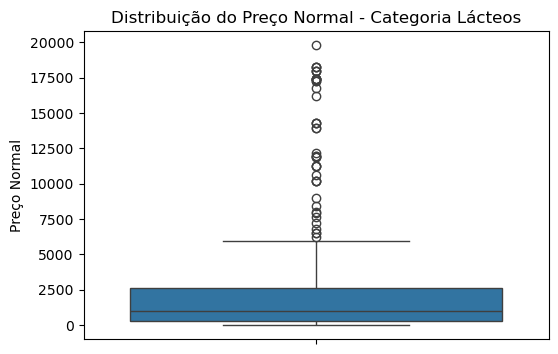

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

categoria_maior_desvio = 'lacteos'

df_lacteos = df[df['Categoria'] == categoria_maior_desvio]

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_lacteos,
    y='Preco_Normal'
)

plt.title('Distribuição do Preço Normal - Categoria Lácteos')
plt.ylabel('Preço Normal')

plt.show()

**O boxplot da categoria lacteos mostra que a distribuição dos preços é bastante espalhada.** A maior parte dos produtos está concentrada em valores mais baixos, só que existem produtos com preços muito altos. Esses valores mais altos identificamos como outliers. Isso explica o desvio padrão elevado e também explica por que a média ficou muito acima da mediana.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

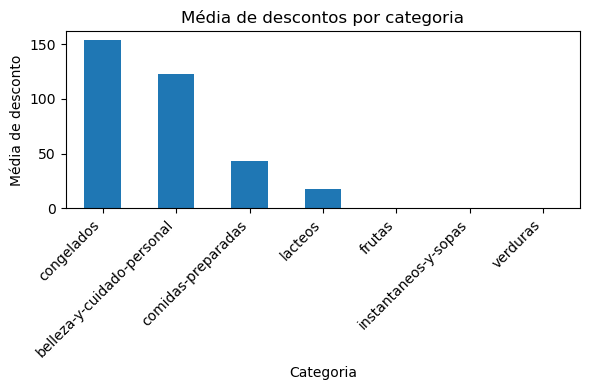

In [127]:
media_desconto = df.groupby('Categoria')['Desconto'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
media_desconto.plot(kind='bar')
plt.title('Média de descontos por categoria')
plt.xlabel('Categoria')
plt.ylabel('Média de desconto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

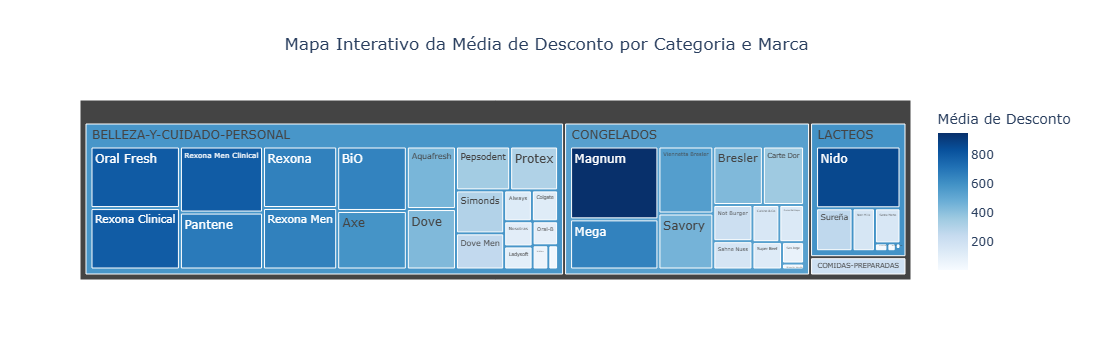

In [128]:
import plotly.express as px

mapa_desconto = df.groupby(['Categoria', 'Marca'], as_index=False)['Desconto'].mean()

mapa_desconto = mapa_desconto.rename(columns={
    'Desconto': 'Média de Desconto'
})

mapa_desconto['Categoria Destaque'] = mapa_desconto['Categoria'].str.upper()

fig = px.treemap(
    mapa_desconto,
    path=['Categoria Destaque', 'Marca'],
    values='Média de Desconto',
    color='Média de Desconto',
    color_continuous_scale='Blues',
    title='Mapa Interativo da Média de Desconto por Categoria e Marca'
)

fig.update_layout(
    title_x=0.5,
    coloraxis_colorbar_title='Média de Desconto'
)

fig.show()

# Conclusão

Com a análise, foi possível perceber que a categoria **lacteos** tem a maior variação de preços. Isso acontece porque existem produtos com valores muito altos dentro da categoria, o que puxa a média para cima e faz com que ela fique acima da mediana.

Também foi possível observar que várias categorias possuem média maior que a mediana, indicando que alguns preços mais altos influenciam o resultado. Nesse cenário, a mediana ajuda a representar melhor o preço típico dos produtos, principalmente quando existem outliers.

No boxplot da categoria **lacteos**, essa variação ficou mais evidente, pois aparecem muitos valores fora do padrão, principalmente em preços mais altos.

Na análise de descontos, as categorias **congelados** e **belleza-y-cuidado-personal** apresentaram as maiores médias, mostrando maior intensidade de desconto nessas categorias.

De forma geral, a análise mostrou como média, mediana, desvio padrão, boxplot e gráficos podem ser usados em conjunto para entender melhor o comportamento dos preços e descontos por categoria.